In [6]:
# explore deltatime 
import dask.dataframe as dd
import glob, os

path = r'C:\Users\Ahmed Mamdouh\Desktop\attacktype1\Data'

for file in glob.glob(os.path.join(path, "*.csv")):
    try:
        df_temp = dd.read_csv(
            file,
            on_bad_lines='skip',
            assume_missing=True,
            dtype=str
        )
        cols = df_temp.columns.tolist()
        has_delta = 'deltatime' in cols
        has_epoch = 'Frame Time (Epoch)' in cols
        print(f"{os.path.basename(file)}: deltatime={'✅' if has_delta else '❌'} | Frame Time (Epoch)={'✅' if has_epoch else '❌'}")
    except Exception as e:
        print(f"خطأ في {os.path.basename(file)}: {e}")

DDOS ICMP.csv: deltatime=✅ | Frame Time (Epoch)=✅
DDOS-UDP.csv: deltatime=❌ | Frame Time (Epoch)=✅
DDOSRAW.csv: deltatime=✅ | Frame Time (Epoch)=✅
DOS.csv: deltatime=❌ | Frame Time (Epoch)=✅
FTP Brute Force.csv: deltatime=❌ | Frame Time (Epoch)=✅
FTP_EXP1.csv: deltatime=✅ | Frame Time (Epoch)=✅
FTP_EXP2.csv: deltatime=❌ | Frame Time (Epoch)=✅
Fuzzing.csv: deltatime=❌ | Frame Time (Epoch)=✅
ICMP-Flood.csv: deltatime=❌ | Frame Time (Epoch)=✅
MITM-ARP Spoofing.csv: deltatime=❌ | Frame Time (Epoch)=✅
normal_data.csv: deltatime=❌ | Frame Time (Epoch)=✅
Port Scanning.csv: deltatime=❌ | Frame Time (Epoch)=✅
Remote Code Execution.csv: deltatime=❌ | Frame Time (Epoch)=✅
SQL Injection.csv: deltatime=❌ | Frame Time (Epoch)=✅
SQL-Injection2.csv: deltatime=❌ | Frame Time (Epoch)=✅
SQLinjection-UPDATED.csv: deltatime=❌ | Frame Time (Epoch)=✅
SSH Brute Force.csv: deltatime=❌ | Frame Time (Epoch)=✅
SYN-Flood.csv: deltatime=✅ | Frame Time (Epoch)=✅
XSS-0.csv: deltatime=❌ | Frame Time (Epoch)=✅
XSS-1.cs

In [ ]:
# explore sql & skip files
import dask.dataframe as dd

df_sql_updated = dd.read_csv(
    r'data\merged_dataset.csv',
    on_bad_lines='skip',
    assume_missing=True,
    dtype=str
)

print("columns:", df_sql_updated.columns.tolist())

print("rows :", len(df_sql_updated))

print(df_sql_updated.head())

columns: ['No.', 'Time', 'Source', 'Destination', 'Protocol', 'Length', 'Info', 'frame number', 'frame length', 'Frame Time', 'Frame Time (Epoch)', 'Frame Protocols', 'Ethernet Source', 'Ethernet Destination', 'Ethernet Type', 'IP Source', 'IP Destination', 'IP Length', 'IP TTL', 'IP Flags', 'IP Fragment Offset', 'IP Protocol', 'IP Version', 'IP DSCP Field', 'IP Checksum', 'TCP Source Port', 'TCP Destination Port', 'TCP Length', 'TCP Sequence Number', 'TCP Acknowledgment Number', 'TCP Flags', 'TCP SYN Flag', 'TCP ACK Flag', 'TCP FIN Flag', 'TCP RST Flag', 'TCP Window Size', 'TCP Checksum', 'TCP Stream', 'UDP Source Port', 'UDP Destination Port', 'UDP Length', 'UDP Checksum', 'ICMP Type', 'ICMP Checksum', 'HTTP Request Method', 'HTTP Request URI', 'HTTP Request Version', 'HTTP Full URI', 'HTTP Response Code', 'HTTP User-Agent', 'HTTP Content-Length', 'HTTP Content Type', 'HTTP Cookie', 'HTTP Host', 'HTTP Referer', 'HTTP Location', 'HTTP Authorization', 'HTTP Connection', 'DNS Query Name

In [8]:
df_sql1 = dd.read_csv(r'C:\Users\Ahmed Mamdouh\Desktop\attacktype1\Data\SQL Injection.csv', on_bad_lines='skip', assume_missing=True, dtype=str)
df_sql2 = dd.read_csv(r'C:\Users\Ahmed Mamdouh\Desktop\attacktype1\Data\SQL-Injection2.csv', on_bad_lines='skip', assume_missing=True, dtype=str)

print("SQL Injection columns:", df_sql1.columns.tolist())
print("SQL-Injection2 columns:", df_sql2.columns.tolist())
print("SQLinjection-UPDATED columns:", df_sql_updated.columns.tolist())

print("\nSQL Injection rows:", len(df_sql1))
print("SQL-Injection2 rows:", len(df_sql2))
print("SQLinjection-UPDATED rows:", len(df_sql_updated))

SQL Injection columns: ['No.', 'Time', 'Source', 'Destination', 'Protocol', 'Length', 'Info', 'frame number', 'frame length', 'Frame Time', 'Frame Time (Epoch)', 'Frame Protocols', 'Ethernet Source', 'Ethernet Destination', 'Ethernet Type', 'IP Source', 'IP Destination', 'IP Length', 'IP TTL', 'IP Flags', 'IP Fragment Offset', 'IP Protocol', 'IP Version', 'IP DSCP Field', 'IP Checksum', 'TCP Source Port', 'TCP Destination Port', 'TCP Length', 'TCP Sequence Number', 'TCP Acknowledgment Number', 'TCP Flags', 'TCP SYN Flag', 'TCP ACK Flag', 'TCP FIN Flag', 'TCP RST Flag', 'TCP Window Size', 'TCP Checksum', 'TCP Stream', 'UDP Source Port', 'UDP Destination Port', 'UDP Length', 'UDP Checksum', 'ICMP Type', 'ICMP Checksum', 'HTTP Request Method', 'HTTP Request URI', 'HTTP Request Version', 'HTTP Full URI', 'HTTP Response Code', 'HTTP User-Agent', 'HTTP Content-Length', 'HTTP Content Type', 'HTTP Cookie', 'HTTP Host', 'HTTP Referer', 'HTTP Location', 'HTTP Authorization', 'HTTP Connection', '

# df_final -> analysis

In [9]:
# 1 create "df_final"  & match labels for each attack and calculate deltatime
import dask.dataframe as dd
import glob, os

path = r'C:\Users\Ahmed Mamdouh\Desktop\attacktype1\Data'
exclude_files = ['SQL Injection.csv', 'SQL-Injection2.csv']

labels = {
    'DDOS ICMP.csv': 'DDoS_ICMP',
    'DDOS-UDP.csv': 'DDoS_UDP',
    'DDOSRAW.csv': 'DDoS_RAW',
    'DOS.csv': 'DoS',
    'FTP Brute Force.csv': 'FTP_BruteForce',
    'FTP_EXP1.csv': 'FTP_Exploit',
    'FTP_EXP2.csv': 'FTP_Exploit',
    'Fuzzing.csv': 'Fuzzing',
    'ICMP-Flood.csv': 'ICMP_Flood',
    'MITM-ARP Spoofing.csv': 'MITM_ARP',
    'normal_data.csv': 'Normal',
    'Port Scanning.csv': 'PortScanning',
    'Remote Code Execution.csv': 'RCE',
    'SQLinjection-UPDATED.csv': 'SQL_Injection',
    'SSH Brute Force.csv': 'SSH_BruteForce',
    'SYN-Flood.csv': 'SYN_Flood',
    'XSS-0.csv': 'XSS',
    'XSS-1.csv': 'XSS',
    'XSS-2.csv': 'XSS',
}

has_deltatime = ['DDOS ICMP.csv', 'DDOSRAW.csv', 'FTP_EXP1.csv', 'SYN-Flood.csv']

all_files = glob.glob(os.path.join(path, "*.csv"))
dfs = []

for file in all_files:
    filename = os.path.basename(file)
    if filename in exclude_files:
        print(f"skip : {filename}")
        continue

    try:
        df_temp = dd.read_csv(
            file,
            on_bad_lines='skip',
            assume_missing=True,
            dtype=str
        )
        

        import dask.dataframe as dd
 


        # compute deltatime if not exist
        if filename not in has_deltatime:
            df_temp['Frame Time (Epoch)'] = dd.to_numeric(
                       df_temp['Frame Time (Epoch)'], errors='coerce'
            )
            df_temp['deltatime'] = df_temp['Frame Time (Epoch)'].diff()
            df_temp['deltatime'] = df_temp['deltatime'].fillna(0)
            df_temp['deltatime'] = df_temp['deltatime'].astype('float64')
            
        # match label
        df_temp['label'] = labels.get(filename, 'Unknown')
        
        # assign attack or not
        df_temp['is_attack'] = 0 if filename == 'normal_data.csv' else 1

        dfs.append(df_temp)
        print(f" {filename}: {len(df_temp):,} row | label: {labels.get(filename)}")

    except Exception as e:
        print(f"error {filename}: {e}")

print("\n Merging in progress...")
df_final = dd.concat(dfs, interleave_partitions=True)

print(f"\n Total rows: {len(df_final):,}")
print(f"Labels Distribution :\n{df_final['label'].value_counts().compute()}")

output_path = r'C:\Users\Ahmed Mamdouh\Desktop\attacktype1\merged_dataset.csv'
print("\n saving...")

df_final.to_csv(output_path, single_file=True, index=False)
print(f" saved: {output_path}")

 DDOS ICMP.csv: 199,991 row | label: DDoS_ICMP
 DDOS-UDP.csv: 318,209 row | label: DDoS_UDP
 DDOSRAW.csv: 326,485 row | label: DDoS_RAW
 DOS.csv: 369,288 row | label: DoS
 FTP Brute Force.csv: 121,916 row | label: FTP_BruteForce
 FTP_EXP1.csv: 72,074 row | label: FTP_Exploit
 FTP_EXP2.csv: 135,729 row | label: FTP_Exploit
 Fuzzing.csv: 117,558 row | label: Fuzzing
 ICMP-Flood.csv: 240,082 row | label: ICMP_Flood
 MITM-ARP Spoofing.csv: 96,895 row | label: MITM_ARP
 normal_data.csv: 1,259,470 row | label: Normal
 Port Scanning.csv: 162,319 row | label: PortScanning
 Remote Code Execution.csv: 278,873 row | label: RCE
skip : SQL Injection.csv
skip : SQL-Injection2.csv
 SQLinjection-UPDATED.csv: 269,586 row | label: SQL_Injection
 SSH Brute Force.csv: 139,762 row | label: SSH_BruteForce
 SYN-Flood.csv: 199,949 row | label: SYN_Flood
 XSS-0.csv: 2,128 row | label: XSS
 XSS-1.csv: 2,318 row | label: XSS
 XSS-2.csv: 213,145 row | label: XSS

 Merging in progress...

 Total rows: 4,525,777
La

In [10]:
df_final.shape[0].compute()

4525777

# df -> preprocessing & training

In [2]:
import os
print(os.getcwd())

f:\DEPI\final_one\pulse-detect-net-main\notebook


In [4]:
import pandas as pd

df_final = pd.read_csv(r'F:\DEPI\final_one\pulse-detect-net-main\data\merged_dataset.csv', low_memory=False)
df = df_final.copy()

print(f"Shape: {df.shape}")
print(f"Label dtype: {df['label'].dtype}")

Shape: (4525777, 63)
Label dtype: str


In [10]:
# To show all rows and columns
import pandas as pd

pd.set_option('display.max_columns', None)
pd.reset_option('display.max_rows')


In [11]:
df_final.head()

,No.,Time,Source,Destination,Protocol,Length,Info,frame number,frame length,Frame Time,Frame Time (Epoch),Frame Protocols,Ethernet Source,Ethernet Destination,Ethernet Type,IP Source,IP Destination,IP Length,IP TTL,IP Flags,IP Fragment Offset,IP Protocol,IP Version,IP DSCP Field,IP Checksum,TCP Source Port,TCP Destination Port,TCP Length,TCP Sequence Number,TCP Acknowledgment Number,TCP Flags,TCP SYN Flag,TCP ACK Flag,TCP FIN Flag,TCP RST Flag,TCP Window Size,TCP Checksum,TCP Stream,UDP Source Port,UDP Destination Port,UDP Length,UDP Checksum,ICMP Type,ICMP Checksum,HTTP Request Method,HTTP Request URI,HTTP Request Version,HTTP Full URI,HTTP Response Code,HTTP User-Agent,HTTP Content-Length,HTTP Content Type,HTTP Cookie,HTTP Host,HTTP Referer,HTTP Location,HTTP Authorization,HTTP Connection,DNS Query Name,DNS Query Type,deltatime,label,is_attack
0,810973,196.385550,192.168.1.108,192.168.1.104,ICMP,965,"Echo (ping) request id=0x468d, seq=36184/2266...",810973.0,965,"Mar 2, 2024 19:59:12.713751435 +03",1.709399e+09,eth:ethertype:ip:icmp:data,08:00:27:66:96:d4,08:00:27:4f:81:43,IPv4,192.168.1.108,192.168.1.104,951.0,64.0,0x00,0.0,ICMP,4.0,0x00,0xd60a,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0xb502,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DDoS_ICMP,1
1,447853,112.742874,192.168.1.108,192.168.1.104,ICMP,965,"Echo (ping) request id=0x468d, seq=12946/3742...",447853.0,965,"Mar 2, 2024 19:57:49.071075097 +03",1.709399e+09,eth:ethertype:ip:icmp:data,08:00:27:66:96:d4,08:00:27:4f:81:43,IPv4,192.168.1.108,192.168.1.104,951.0,64.0,0x00,0.0,ICMP,4.0,0x00,0x8b7b,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0x0fc9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DDoS_ICMP,1
2,4252,0.919673,192.168.1.104,192.168.1.108,ICMP,819,"Echo (ping) reply id=0x3b8a, seq=19464/2124...",4252.0,819,"Mar 2, 2024 19:55:57.247873589 +03",1.709399e+09,eth:ethertype:ip:icmp:data,08:00:27:4f:81:43,08:00:27:66:96:d4,IPv4,192.168.1.104,192.168.1.108,805.0,64.0,0x00,0.0,ICMP,4.0,0x00,0xbeb1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0x3a87,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DDoS_ICMP,1
3,785672,189.853770,192.168.1.104,192.168.1.108,ICMP,965,"Echo (ping) reply id=0x468d, seq=8743/10018...",785672.0,965,"Mar 2, 2024 19:59:06.181970708 +03",1.709399e+09,eth:ethertype:ip:icmp:data,08:00:27:4f:81:43,08:00:27:66:96:d4,IPv4,192.168.1.104,192.168.1.108,951.0,64.0,0x00,0.0,ICMP,4.0,0x00,0xc6c1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0x2834,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DDoS_ICMP,1
4,1120610,269.901775,192.168.1.104,192.168.1.108,ICMP,965,"Echo (ping) reply id=0x468d, seq=53685/4654...",1120610.0,965,"Mar 2, 2024 20:00:26.229975801 +03",1.709399e+09,eth:ethertype:ip:icmp:data,08:00:27:4f:81:43,08:00:27:66:96:d4,IPv4,192.168.1.104,192.168.1.108,951.0,64.0,0x00,0.0,ICMP,4.0,0x00,0x3812,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0x78a5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DDoS_ICMP,1


In [12]:
print(list(df_final.columns))

['No.', 'Time', 'Source', 'Destination', 'Protocol', 'Length', 'Info', 'frame number', 'frame length', 'Frame Time', 'Frame Time (Epoch)', 'Frame Protocols', 'Ethernet Source', 'Ethernet Destination', 'Ethernet Type', 'IP Source', 'IP Destination', 'IP Length', 'IP TTL', 'IP Flags', 'IP Fragment Offset', 'IP Protocol', 'IP Version', 'IP DSCP Field', 'IP Checksum', 'TCP Source Port', 'TCP Destination Port', 'TCP Length', 'TCP Sequence Number', 'TCP Acknowledgment Number', 'TCP Flags', 'TCP SYN Flag', 'TCP ACK Flag', 'TCP FIN Flag', 'TCP RST Flag', 'TCP Window Size', 'TCP Checksum', 'TCP Stream', 'UDP Source Port', 'UDP Destination Port', 'UDP Length', 'UDP Checksum', 'ICMP Type', 'ICMP Checksum', 'HTTP Request Method', 'HTTP Request URI', 'HTTP Request Version', 'HTTP Full URI', 'HTTP Response Code', 'HTTP User-Agent', 'HTTP Content-Length', 'HTTP Content Type', 'HTTP Cookie', 'HTTP Host', 'HTTP Referer', 'HTTP Location', 'HTTP Authorization', 'HTTP Connection', 'DNS Query Name', 'DNS Q

# Check if any rows were skipped

In [8]:
import os
def count_lines(file):
    with open(file, 'r', encoding='utf-8', errors='ignore') as f:
        return sum(1 for _ in f) - 1  # -1 because not count header

raw_counts = {}
for file in all_files:
    filename = os.path.basename(file)
    if filename in exclude_files:
        continue
    raw_counts[filename] = count_lines(file)

NameError: name 'all_files' is not defined

In [9]:
total_raw = 0
total_dask = 0

for file in all_files:
    filename = os.path.basename(file)
    if filename in exclude_files:
        continue

    try:
        df_temp = dd.read_csv(
            file,
            on_bad_lines='skip',
            assume_missing=True,
            dtype=str
        )

        dask_count = df_temp.shape[0].compute()
        raw_count = raw_counts.get(filename, 0)

        total_raw += raw_count
        total_dask += dask_count

        skipped = raw_count - dask_count

        print(f"{filename}: skipped = {skipped}")

    except Exception as e:
        print(f"error in {filename}: {e}")

total_skipped = total_raw - total_dask

print("\n total:")
print(f"1 total original: {total_raw:,}")
print(f"2 total read: {total_dask:,}")
print(f"3 total skipped: {total_skipped:,}")
percentage = (total_skipped / total_raw) * 100
print(f" Percentage of data loss: {percentage:.4f}%")


NameError: name 'all_files' is not defined

*STEP 1 => understanding the data*

In [13]:
df_final.head()

,No.,Time,Source,Destination,Protocol,Length,Info,frame number,frame length,Frame Time,Frame Time (Epoch),Frame Protocols,Ethernet Source,Ethernet Destination,Ethernet Type,IP Source,IP Destination,IP Length,IP TTL,IP Flags,IP Fragment Offset,IP Protocol,IP Version,IP DSCP Field,IP Checksum,TCP Source Port,TCP Destination Port,TCP Length,TCP Sequence Number,TCP Acknowledgment Number,TCP Flags,TCP SYN Flag,TCP ACK Flag,TCP FIN Flag,TCP RST Flag,TCP Window Size,TCP Checksum,TCP Stream,UDP Source Port,UDP Destination Port,UDP Length,UDP Checksum,ICMP Type,ICMP Checksum,HTTP Request Method,HTTP Request URI,HTTP Request Version,HTTP Full URI,HTTP Response Code,HTTP User-Agent,HTTP Content-Length,HTTP Content Type,HTTP Cookie,HTTP Host,HTTP Referer,HTTP Location,HTTP Authorization,HTTP Connection,DNS Query Name,DNS Query Type,deltatime,label,is_attack
0,810973,196.385550,192.168.1.108,192.168.1.104,ICMP,965,"Echo (ping) request id=0x468d, seq=36184/2266...",810973.0,965,"Mar 2, 2024 19:59:12.713751435 +03",1.709399e+09,eth:ethertype:ip:icmp:data,08:00:27:66:96:d4,08:00:27:4f:81:43,IPv4,192.168.1.108,192.168.1.104,951.0,64.0,0x00,0.0,ICMP,4.0,0x00,0xd60a,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0xb502,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DDoS_ICMP,1
1,447853,112.742874,192.168.1.108,192.168.1.104,ICMP,965,"Echo (ping) request id=0x468d, seq=12946/3742...",447853.0,965,"Mar 2, 2024 19:57:49.071075097 +03",1.709399e+09,eth:ethertype:ip:icmp:data,08:00:27:66:96:d4,08:00:27:4f:81:43,IPv4,192.168.1.108,192.168.1.104,951.0,64.0,0x00,0.0,ICMP,4.0,0x00,0x8b7b,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0x0fc9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DDoS_ICMP,1
2,4252,0.919673,192.168.1.104,192.168.1.108,ICMP,819,"Echo (ping) reply id=0x3b8a, seq=19464/2124...",4252.0,819,"Mar 2, 2024 19:55:57.247873589 +03",1.709399e+09,eth:ethertype:ip:icmp:data,08:00:27:4f:81:43,08:00:27:66:96:d4,IPv4,192.168.1.104,192.168.1.108,805.0,64.0,0x00,0.0,ICMP,4.0,0x00,0xbeb1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0x3a87,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DDoS_ICMP,1
3,785672,189.853770,192.168.1.104,192.168.1.108,ICMP,965,"Echo (ping) reply id=0x468d, seq=8743/10018...",785672.0,965,"Mar 2, 2024 19:59:06.181970708 +03",1.709399e+09,eth:ethertype:ip:icmp:data,08:00:27:4f:81:43,08:00:27:66:96:d4,IPv4,192.168.1.104,192.168.1.108,951.0,64.0,0x00,0.0,ICMP,4.0,0x00,0xc6c1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0x2834,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DDoS_ICMP,1
4,1120610,269.901775,192.168.1.104,192.168.1.108,ICMP,965,"Echo (ping) reply id=0x468d, seq=53685/4654...",1120610.0,965,"Mar 2, 2024 20:00:26.229975801 +03",1.709399e+09,eth:ethertype:ip:icmp:data,08:00:27:4f:81:43,08:00:27:66:96:d4,IPv4,192.168.1.104,192.168.1.108,951.0,64.0,0x00,0.0,ICMP,4.0,0x00,0x3812,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0x78a5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DDoS_ICMP,1


No. (Index): A unique sequence number for each packet, typically dropped during training as it holds no predictive value.

Timestamp: The time at which the network activity occurred.
Source IP Address: The IP address of the sender or initiator of the network traffic.
Destination IP Address: The IP address of the sender or initiator of the network traffic.
Protocol: The communication protocol used (e.g., TCP, UDP, ICMP).
Length / frame length: The size of the packet in bytes; constant or abnormal sizes often indicate DDoS attacks.
Info: A textual summary of the packet content, useful for manual analysis but often dropped in ML.
frame number: A sequential index that should be removed to avoid model overfitting.
Frame Time (Epoch): The raw numerical timestamp used for calculating traffic frequency and gaps.
Frame Protocols: The complete stack of protocols within the frame, helping identify anomalous communication paths.
Ethernet Source / Destination: The physical MAC addresses, crucial for detecting IP spoofing and identifying specific hardware.
Ethernet Type: Indicates the network layer protocol (e.g., IPv4), helping the model classify the general traffic structure.
IP Source / Destination: Logical addresses used to route traffic; vital for detecting spoofing and mapping attack flows.
IP TTL (Time To Live): Limits packet lifespan; used by attackers for OS fingerprinting and by defenders to trace attack origins.
IP Flags: Controls packet fragmentation; often manipulated to bypass firewalls or IDS.
IP Fragment Offset: Indicates the position of a fragment; crucial for detecting "Teardrop" or reassembly attacks.
IP Protocol: Identifies the next-level protocol (TCP/UDP); helps the model categorize the nature of the communication.
IP Version: Usually IPv4 or IPv6; defines the structure of the IP header.
IP Checksum: A mathematical value used to verify header integrity; errors can indicate data corruption or malicious tampering.
TCP Source/Destination Port: Identifies specific applications; crucial for detecting Port Scanning attacks.
TCP Length: The size of the TCP payload; helps in spotting buffer overflow attempts.
TCP Sequence/ACK Numbers: Used for session tracking; anomalies here suggest Session Hijacking or injection attacks.
TCP Flags: A combined field of all control bits; serves as a primary signature for various network attacks.
TCP SYN Flag: Indicates connection requests; a high frequency from one source signals a SYN Flood (DDoS) attack.
TCP ACK Flag: Confirms receipt of data; used by attackers to map out firewall rules.
TCP ACK Flag: Confirms receipt of data; used by attackers to map out firewall rules.
HTTP Request Method: Identifies the action (GET/POST); critical for spotting injection attacks.
HTTP URI (Request/Full): The actual web path; scanned by ML models for malicious scripts like SQLi or XSS.
HTTP Response Code: Status codes like 404 or 500 help track brute-forcing or server crashes during attacks.
HTTP User-Agent: Identifies the browser or tool used; used to detect automated hacking scripts.
HTTP Content-Length/Type: Details about the payload size; helps identify anomalies in web traffic.
HTTP Cookie/Authorization: Security headers; monitored for session theft or unauthorized access attempts.
DNS Query Name/Type: Records the domain requested; used to detect DNS-based attacks and data leaks.

*STEP 2 => remove columns that are not useful from the dataset.*

In [14]:
# 2 drop columns not useful

cols_to_drop = [
    # Identifiers — leakage
    'No.','frame number',
    # Checksums — no value
    'IP Checksum','TCP Checksum','UDP Checksum','ICMP Checksum',
    # Metadata
    'Info'
]
df_final = df_final.drop(columns=[c for c in cols_to_drop if c in df_final.columns])
print(f"Columns remaining: {len(df_final.columns)}")

Columns remaining: 56


In [15]:

cols_to_drop = [
    # Identifiers — leakage
    'No.','frame number',
    # Checksums — no value
    'IP Checksum','TCP Checksum','UDP Checksum','ICMP Checksum',
    # Metadata
    'Info'
]
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

*STEP 3 => Removed redundant, and constant features*

In [17]:
# 3 These columns may represent the same concept, so we analyze their correlation and uniqueness

import pandas as pd

check_cols = [
    'Length', 'frame length', 'IP Length', 'TCP Length', 'UDP Length',
    'IP DSCP Field', 'IP Fragment Offset',
    'TCP Sequence Number', 'TCP Acknowledgment Number',
    'IP Version'
]

# take a random sample from selected columns only
sample1 = df_final[check_cols].sample(frac=0.01, random_state=42)

# convert all values to numeric, non-numeric values become NaN
sample_numeric = sample1.apply(pd.to_numeric, errors='coerce')

## 1- handle length columns
size_cols = ['Length', 'frame length', 'IP Length', 'TCP Length', 'UDP Length']

print("=== Correlation on random sample ===")
print(sample_numeric[size_cols].corr().round(2))

# Correlation explanation:
# Close to 1 → columns are very similar
# Close to 0 → no relationship
# Close to -1 → inverse relationship
# Used to check if columns are duplicate or strongly related


print("\n  Unique values and missing values per column ")
for col in size_cols + [
    'IP DSCP Field', 'IP Fragment Offset', 'IP Version',
    'TCP Sequence Number', 'TCP Acknowledgment Number'
]:
    if col in sample_numeric.columns:
        uniq = sample_numeric[col].nunique()
        nulls = sample_numeric[col].isna().sum()
        print(f"{col}: {uniq} unique values | nulls: {nulls:,}")

=== Correlation on random sample ===
              Length  frame length  IP Length  TCP Length  UDP Length
Length          1.00          1.00        1.0         1.0        0.93
frame length    1.00          1.00        1.0         1.0        0.93
IP Length       1.00          1.00        1.0         1.0        1.00
TCP Length      1.00          1.00        1.0         1.0         NaN
UDP Length      0.93          0.93        1.0         NaN        1.00

  Unique values and missing values per column 
Length: 1300 unique values | nulls: 0
frame length: 1300 unique values | nulls: 0
IP Length: 1235 unique values | nulls: 2,542
TCP Length: 796 unique values | nulls: 9,780
UDP Length: 41 unique values | nulls: 41,767
IP DSCP Field: 0 unique values | nulls: 45,258
IP Fragment Offset: 1 unique values | nulls: 2,542
IP Version: 2 unique values | nulls: 2,539
TCP Sequence Number: 3993 unique values | nulls: 9,780
TCP Acknowledgment Number: 5011 unique values | nulls: 9,780


In [18]:

final_drop_list = [
    'frame length', 'IP Length', 'TCP Length', 'UDP Length', 
    'IP DSCP Field',                                        
    'IP Fragment Offset'                                    
]
df_final = df_final.drop(columns=[c for c in final_drop_list if c in df_final.columns])

print(" Done! Data is now leaner and cleaner.")

 Done! Data is now leaner and cleaner.


In [19]:
final_drop_list = [
    'frame length', 'IP Length', 'TCP Length', 'UDP Length', 
    'IP DSCP Field',                                        
    'IP Fragment Offset'                                    
]

df = df.drop(columns=[c for c in final_drop_list if c in df.columns])

In [21]:
## 2- handle Protocol

# Take a random sample from the full dataset (all columns)
sample = df_final.sample(frac=0.01, random_state=42)


match_percentage = (sample['Protocol'] == sample['IP Protocol']).mean()
print(f"Match percentage : {match_percentage * 100}%")

Match percentage : 79.60360599231076%


In [24]:
print(list(sample.columns))

['Time', 'Source', 'Destination', 'Protocol', 'Length', 'Frame Time', 'Frame Time (Epoch)', 'Frame Protocols', 'Ethernet Source', 'Ethernet Destination', 'Ethernet Type', 'IP Source', 'IP Destination', 'IP TTL', 'IP Flags', 'IP Protocol', 'IP Version', 'TCP Source Port', 'TCP Destination Port', 'TCP Sequence Number', 'TCP Acknowledgment Number', 'TCP Flags', 'TCP SYN Flag', 'TCP ACK Flag', 'TCP FIN Flag', 'TCP RST Flag', 'TCP Window Size', 'TCP Stream', 'UDP Source Port', 'UDP Destination Port', 'ICMP Type', 'HTTP Request Method', 'HTTP Request URI', 'HTTP Request Version', 'HTTP Full URI', 'HTTP Response Code', 'HTTP User-Agent', 'HTTP Content-Length', 'HTTP Content Type', 'HTTP Cookie', 'HTTP Host', 'HTTP Referer', 'HTTP Location', 'HTTP Authorization', 'HTTP Connection', 'DNS Query Name', 'DNS Query Type', 'deltatime', 'label', 'is_attack']


In [22]:
# 1. Filter rows where Protocol and IP Protocol are different
# We use .astype(str) to handle potential NaNs and ensure consistent comparison
discrepancies = sample[sample['Protocol'].astype(str) != sample['IP Protocol'].astype(str)]

# 2. Display the count and the first 5 examples of these differences
print(f" Protocol Discrepancy Analysis ")
print(f"Total rows with differences in sample: {len(discrepancies)}")
print(f"Percentage of non-matching rows: {len(discrepancies) / len(sample) * 100:.2f}%")

print("\n Top 5 Examples of Mismatched Protocols ")
# Showing Protocol (App Layer), IP Protocol (Transport Layer), and Info (Context)
print(discrepancies[['Protocol', 'IP Protocol']].head(5))

 Protocol Discrepancy Analysis 
Total rows with differences in sample: 9231
Percentage of non-matching rows: 20.40%

 Top 5 Examples of Mismatched Protocols 
        Protocol IP Protocol
3473225     HTTP         TCP
3527412     HTTP         TCP
1969716      ARP         NaN
2862027     HTTP         TCP
229965      ICMP    ICMP,UDP


In [23]:
print("Protocol values:")
print(sample['Protocol'].value_counts().head(10))

print("\nIP Protocol values:")
print(sample['IP Protocol'].value_counts().head(10))

Protocol values:
Protocol
TCP        29049
ICMP        6743
HTTP        5525
UDP         1733
ARP         1041
SSHv2        612
FTP          270
DNS          249
TLSv1.3        5
TFTP           5
Name: count, dtype: int64

IP Protocol values:
IP Protocol
TCP         35478
ICMP         5245
UDP          1993
ICMP,UDP     1498
Name: count, dtype: int64


In [24]:
# IP Protocol
df_final = df_final.drop(columns=['IP Protocol'])

print(f" remaining columns: {len(df_final.columns)}")
print(df_final.columns.tolist())

 remaining columns: 49
['Time', 'Source', 'Destination', 'Protocol', 'Length', 'Frame Time', 'Frame Time (Epoch)', 'Frame Protocols', 'Ethernet Source', 'Ethernet Destination', 'Ethernet Type', 'IP Source', 'IP Destination', 'IP TTL', 'IP Flags', 'IP Version', 'TCP Source Port', 'TCP Destination Port', 'TCP Sequence Number', 'TCP Acknowledgment Number', 'TCP Flags', 'TCP SYN Flag', 'TCP ACK Flag', 'TCP FIN Flag', 'TCP RST Flag', 'TCP Window Size', 'TCP Stream', 'UDP Source Port', 'UDP Destination Port', 'ICMP Type', 'HTTP Request Method', 'HTTP Request URI', 'HTTP Request Version', 'HTTP Full URI', 'HTTP Response Code', 'HTTP User-Agent', 'HTTP Content-Length', 'HTTP Content Type', 'HTTP Cookie', 'HTTP Host', 'HTTP Referer', 'HTTP Location', 'HTTP Authorization', 'HTTP Connection', 'DNS Query Name', 'DNS Query Type', 'deltatime', 'label', 'is_attack']


In [25]:
df = df.drop(columns=['IP Protocol'])

*STEP 4 => Remove dublicate rows*

In [26]:
# 4 Dask's way to drop duplicates on full dataset
print("Dropping duplicates...")
total_before = len(df_final)

df_final = df_final.drop_duplicates()

total_after = len(df_final)
dropped = total_before - total_after

print(f"Before: {total_before:,}")
print(f"After:  {total_after:,}")
print(f"Dropped: {dropped:,} rows ({dropped/total_before*100:.2f}%)")

Dropping duplicates...
Before: 4,525,777
After:  4,467,762
Dropped: 58,015 rows (1.28%)


In [27]:
df = df.drop_duplicates()

In [28]:
print(list(sample.columns))

['Time', 'Source', 'Destination', 'Protocol', 'Length', 'Frame Time', 'Frame Time (Epoch)', 'Frame Protocols', 'Ethernet Source', 'Ethernet Destination', 'Ethernet Type', 'IP Source', 'IP Destination', 'IP TTL', 'IP Flags', 'IP Protocol', 'IP Version', 'TCP Source Port', 'TCP Destination Port', 'TCP Sequence Number', 'TCP Acknowledgment Number', 'TCP Flags', 'TCP SYN Flag', 'TCP ACK Flag', 'TCP FIN Flag', 'TCP RST Flag', 'TCP Window Size', 'TCP Stream', 'UDP Source Port', 'UDP Destination Port', 'ICMP Type', 'HTTP Request Method', 'HTTP Request URI', 'HTTP Request Version', 'HTTP Full URI', 'HTTP Response Code', 'HTTP User-Agent', 'HTTP Content-Length', 'HTTP Content Type', 'HTTP Cookie', 'HTTP Host', 'HTTP Referer', 'HTTP Location', 'HTTP Authorization', 'HTTP Connection', 'DNS Query Name', 'DNS Query Type', 'deltatime', 'label', 'is_attack']


*STEP 5 => Handling nulls , feature selection , feature engineer*

In [30]:
#5 Calculate null counts on full dataset using Dask
print("Calculating nulls on full dataset...")

null_counts = df_final.isnull().sum()
total_rows = len(df_final)

null_stats = pd.DataFrame({
    'null_count': null_counts,
    'null_pct': (null_counts / total_rows * 100).round(2)
}).sort_values('null_pct', ascending=False)

# Show only columns that have nulls
print(null_stats[null_stats['null_count'] > 0])

Calculating nulls on full dataset...
                           null_count  null_pct
HTTP Authorization            4465494     99.95
HTTP Location                 4452997     99.67
DNS Query Name                4442769     99.44
DNS Query Type                4442769     99.44
HTTP Cookie                   4436153     99.29
HTTP Referer                  4419252     98.91
HTTP Connection               4249533     95.12
HTTP User-Agent               4245070     95.02
HTTP Content-Length           4233542     94.76
HTTP Response Code            4229665     94.67
HTTP Request URI              4213062     94.30
HTTP Request Method           4213062     94.30
HTTP Host                     4213135     94.30
HTTP Full URI                 4213135     94.30
HTTP Request Version          4213062     94.30
HTTP Content Type             4203352     94.08
UDP Destination Port          4119460     92.20
UDP Source Port               4119460     92.20
ICMP Type                     3840166     85.95
TCP

# 1"Let's handle the 'HTTP Request Methods'."

In [32]:
sample = df_final.sample(frac=0.01, random_state=42)

http_response_no_method = sample[
     (sample['HTTP Response Code'].notnull()) & 
     (sample['HTTP Request Method'].isnull())
 ]
print(f"HTTP Responses without Method: {len(http_response_no_method)}")
print(f"Total HTTP packets in sample: {sample['HTTP Response Code'].notnull().sum()}")
print(http_response_no_method[['HTTP Response Code', 'HTTP Request Method', 'Length']].head())

HTTP Responses without Method: 2365
Total HTTP packets in sample: 2365
        HTTP Response Code HTTP Request Method  Length
2429328                401                 NaN    1371
1637101                404                 NaN     521
2501589                401                 NaN    1371
3158964                200                 NaN    2846
4410694                200                 NaN    1616


HTTP Response Code  200.0  204.0  301.0  302.0  303.0  304.0  400.0  401.0  \
label                                                                        
DoS                  1.00   0.00   0.00   0.00    0.0   0.00   0.00   0.00   
FTP_BruteForce       0.00   1.00   0.00   0.00    0.0   0.00   0.00   0.00   
FTP_Exploit          1.00   0.00   0.00   0.00    0.0   0.00   0.00   0.00   
Fuzzing              0.00   0.00   0.00   0.23    0.0   0.00   0.00   0.00   
Normal               0.49   0.00   0.00   0.00    0.0   0.02   0.00   0.31   
PortScanning         0.64   0.00   0.00   0.00    0.0   0.00   0.14   0.00   
RCE                  0.00   0.00   0.00   0.00    0.0   0.00   0.00   0.00   
SQL_Injection        0.48   0.00   0.00   0.18    0.0   0.00   0.00   0.00   
SSH_BruteForce       0.33   0.67   0.00   0.00    0.0   0.00   0.00   0.00   
XSS                  0.83   0.00   0.02   0.01    0.0   0.03   0.00   0.00   

HTTP Response Code  403.0  404.0  500.0  505.0  
label         

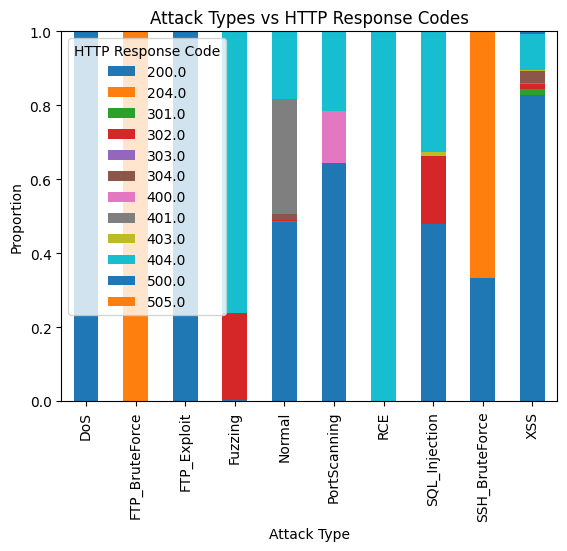

In [33]:
import pandas as pd
import matplotlib.pyplot as plt


check_sample = df_final.sample(frac=0.05, random_state=42)

check_sample['HTTP Response Code'] = pd.to_numeric(
    check_sample['HTTP Response Code'], errors='coerce'
)

response_analysis = pd.crosstab(
    check_sample['label'],
    check_sample['HTTP Response Code'],
    normalize='index'
)


print(response_analysis.round(2))

print(" Relationship between Attack Types and HTTP Response Codes ")

response_analysis.plot(kind='bar', stacked=True)
plt.title("Attack Types vs HTTP Response Codes")
plt.xlabel("Attack Type")
plt.ylabel("Proportion")
plt.show()

In [34]:
print(list(sample.columns))

['Time', 'Source', 'Destination', 'Protocol', 'Length', 'Frame Time', 'Frame Time (Epoch)', 'Frame Protocols', 'Ethernet Source', 'Ethernet Destination', 'Ethernet Type', 'IP Source', 'IP Destination', 'IP TTL', 'IP Flags', 'IP Version', 'TCP Source Port', 'TCP Destination Port', 'TCP Sequence Number', 'TCP Acknowledgment Number', 'TCP Flags', 'TCP SYN Flag', 'TCP ACK Flag', 'TCP FIN Flag', 'TCP RST Flag', 'TCP Window Size', 'TCP Stream', 'UDP Source Port', 'UDP Destination Port', 'ICMP Type', 'HTTP Request Method', 'HTTP Request URI', 'HTTP Request Version', 'HTTP Full URI', 'HTTP Response Code', 'HTTP User-Agent', 'HTTP Content-Length', 'HTTP Content Type', 'HTTP Cookie', 'HTTP Host', 'HTTP Referer', 'HTTP Location', 'HTTP Authorization', 'HTTP Connection', 'DNS Query Name', 'DNS Query Type', 'deltatime', 'label', 'is_attack']


In [35]:
# 1. HTTP Request features
df_final['is_http_request'] = df_final['HTTP Request Method'].notnull().astype(int)
df_final['is_suspicious_method'] = df_final['HTTP Request Method'].isin(
    ['POST', 'OPTIONS', 'PROPFIND']
).astype(int)

# 2. HTTP Response features
df_final['is_http_response'] = df_final['HTTP Response Code'].notnull().astype(int)
df_final['is_http_success'] = (df_final['HTTP Response Code'] == '200').astype(int)
df_final['is_http_error'] = df_final['HTTP Response Code'].str.startswith(
    ('4', '5'), na=False
).astype(int)
df_final['is_http_redirect'] = df_final['HTTP Response Code'].str.startswith(
    '3', na=False
).astype(int)

# 3. Drop original columns
cols_to_drop_now = ['HTTP Request Method', 'HTTP Response Code']
df_final = df_final.drop(columns=[c for c in cols_to_drop_now if c in df_final.columns])

print(" Done!")
print(f"New features added: is_http_request, is_suspicious_method, is_http_response, is_http_success, is_http_error, is_http_redirect")
print(f"Total columns now: {len(df_final.columns)}")

 Done!
New features added: is_http_request, is_suspicious_method, is_http_response, is_http_success, is_http_error, is_http_redirect
Total columns now: 53


In [36]:
# 1. HTTP Request features
df['is_http_request'] = df['HTTP Request Method'].notnull().astype(int)
df['is_suspicious_method'] = df['HTTP Request Method'].isin(
    ['POST', 'OPTIONS', 'PROPFIND']
).astype(int)

# 2. HTTP Response features
df['is_http_response'] = df['HTTP Response Code'].notnull().astype(int)
df['is_http_success'] = (df['HTTP Response Code'] == '200').astype(int)
df['is_http_error'] = df['HTTP Response Code'].str.startswith(
    ('4', '5'), na=False
).astype(int)
df['is_http_redirect'] = df['HTTP Response Code'].str.startswith(
    '3', na=False
).astype(int)

# 3. Drop original columns
cols_to_drop_now = ['HTTP Request Method', 'HTTP Response Code']
df = df.drop(columns=[c for c in cols_to_drop_now if c in df.columns])

print(" Done!")
print(f"Total columns now: {len(df.columns)}")

 Done!
Total columns now: 53


# 2"Let's handle the 'HTTP User-Agent'."

In [37]:
sample['HTTP User-Agent'].value_counts()

HTTP User-Agent
ApacheBench/2.3                                                                                                                                                                                                                                                                                                                                837
Fuzz Faster U Fool v2.1.0-dev                                                                                                                                                                                                                                                                                                                  351
Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/108.0.0.0 Safari/537.36 Edg/108.0.1462.46                                                                                                                                                                                 

# "Feature engineering for 'HTTP User-Agent' and drop column" 

In [38]:
# Is it a known attack tool? (most important)
df_final['is_attack_tool'] = df_final['HTTP User-Agent'].str.contains(
    r'sqlmap|ffuf|fuzz|apachebench|nmap|nikto|masscan|hydra|metasploit',
    case=False, na=False
).astype(int)

# Is it a real browser?
df_final['is_browser'] = df_final['HTTP User-Agent'].str.contains(
    r'mozilla|chrome|firefox|safari|edge',
    case=False, na=False
).astype(int)

# Is it a script/automation tool? (not necessarily attack)
df_final['is_script'] = df_final['HTTP User-Agent'].str.contains(
    r'python|curl|wget|requests|go-http',
    case=False, na=False
).astype(int)

# Drop original column
df_final = df_final.drop(
    columns=['HTTP User-Agent'],
    errors='ignore'
)

print(f" Done! Added: is_attack_tool, is_browser, is_script")



 Done! Added: is_attack_tool, is_browser, is_script


In [39]:
# Is it a known attack tool? (most important)
df['is_attack_tool'] = df['HTTP User-Agent'].str.contains(
    r'sqlmap|ffuf|fuzz|apachebench|nmap|nikto|masscan|hydra|metasploit',
    case=False, na=False
).astype(int)

# Is it a real browser?
df['is_browser'] = df['HTTP User-Agent'].str.contains(
    r'mozilla|chrome|firefox|safari|edge',
    case=False, na=False
).astype(int)

# Is it a script/automation tool? (not necessarily attack)
df['is_script'] = df['HTTP User-Agent'].str.contains(
    r'python|curl|wget|requests|go-http',
    case=False, na=False
).astype(int)

# Drop original column
df = df.drop(columns=['HTTP User-Agent'], errors='ignore')

print(" Done! Added: is_attack_tool, is_browser, is_script")
print(f"Total columns now: {len(df.columns)}")

 Done! Added: is_attack_tool, is_browser, is_script
Total columns now: 55


# 3"Let's handle the 'HTTP Request URI'."

In [40]:
sample['HTTP Full URI'].value_counts()

HTTP Full URI
http://192.168.1.104/WebGoat/attack                371
http://192.168.1.104/                              321
http://192.168.1.104/vicnum/guessnum.html          241
http://192.168.1.109/dvwa/vulnerabilities/sqli/    131
http://192.168.1.104/webgoat                       114
                                                  ... 
http://10.10.0.50/dvwa/crm                           1
http://192.168.1.104/wordpress/?p=1                  1
http://10.10.0.50/dvwa/about-us                      1
http://192.168.1.104/?BLGQZV                         1
http://192.168.1.109/dvwa/shop_closed                1
Name: count, Length: 1247, dtype: int64

In [41]:
sample['HTTP Request URI'].value_counts()

HTTP Request URI
/WebGoat/attack                371
/                              323
/vicnum/guessnum.html          241
/dvwa/vulnerabilities/sqli/    131
/webgoat                       114
                              ... 
/dvwa/crm                        1
/wordpress/?p=1                  1
/dvwa/about-us                   1
/?BLGQZV                         1
/dvwa/shop_closed                1
Name: count, Length: 1243, dtype: int64

In [42]:
# Convert PyArrow strings to regular Python strings first
sample = sample.convert_dtypes(dtype_backend='numpy_nullable')

uri = sample['HTTP Request URI'].fillna('')

print(" URI Patterns ")
print(f"Has sqli pattern: {uri.str.contains(r'sqli|union|select|insert|drop|--|%27|%22', case=False, na=False).sum()}")
print(f"Has suspicious path: {uri.str.contains(r'admin|backup|shell|cmd|config|passwd', case=False, na=False).sum()}")
print(f"Has query params (?): {uri.str.contains(r'\?', na=False).sum()}")
print(f"Has vuln app: {uri.str.contains(r'dvwa|webgoat|vicnum|wackopicko|mutillidae', case=False, na=False).sum()}")

print("\n Sample URIs per pattern ")
print(" SQLi URIs ")
print(uri[uri.str.contains(r'sqli|union|select', case=False, na=False)].value_counts().head(5))

print("\n Suspicious path URIs ")
print(uri[uri.str.contains(r'admin|backup|shell|cmd', case=False, na=False)].value_counts().head(5))

print("\n Vuln app URIs ")
print(uri[uri.str.contains(r'dvwa|webgoat|vicnum', case=False, na=False)].value_counts().head(5))

 URI Patterns 
Has sqli pattern: 203
Has suspicious path: 59
Has query params (?): 531
Has vuln app: 1708

 Sample URIs per pattern 
 SQLi URIs 
HTTP Request URI
/dvwa/vulnerabilities/sqli/                                                                                                                                                                                     131
/dvwa/vulnerabilities/sqli/%27%29%20AS%20MQRj%20WHERE%209835%3D9835%20AND%20EXTRACTVALUE%287976%2CCONCAT%280x5c%2C0x7176626b71%2C%28SELECT%20%28ELT%287976%3D7976%2C1%29%29%29%2C0x716b6b7171%29%29--%20LkOf      1
/dvwa/vulnerabilities/sqli/%27%29%29%29%20RLIKE%20%28SELECT%20%28CASE%20WHEN%20%288808%3D8808%29%20THEN%20%27%27%20ELSE%200x28%20END%29%29%20AND%20%28%28%28%27bBNY%27%3D%27bBNY                                  1
/dvwa/vulnerabilities/sqli/%20WHERE%209685%3D9685%20WAITFOR%20DELAY%20%270%3A0%3A5%27--%20sUfp                                                                                                            

# "Feature engineering for 'HTTP Request URI' and drop column" 

In [43]:
# Only keep uri_has_params - it's the only reliable feature
uri = df_final['HTTP Request URI'].fillna('')

df_final['uri_has_params'] = uri.str.contains(
    r'\?', na=False
).astype(int)

# Drop both URI columns
df_final = df_final.drop(
    columns=['HTTP Request URI', 'HTTP Full URI'],
    errors='ignore'
)

print(" Done! Kept only: uri_has_params")
print(f"Total columns now: {len(df_final.columns)}")

 Done! Kept only: uri_has_params
Total columns now: 54


In [44]:
# Only keep uri_has_params - it's the only reliable feature
uri = df['HTTP Request URI'].fillna('')

df['uri_has_params'] = uri.str.contains(
    r'\?', na=False
).astype(int)

# Drop both URI columns
df = df.drop(
    columns=['HTTP Request URI', 'HTTP Full URI'],
    errors='ignore'
)

print(" Done! Kept only: uri_has_params")
print(f"Total columns now: {len(df.columns)}")

 Done! Kept only: uri_has_params
Total columns now: 54


In [45]:
df_final['is_http_1_0'] = (df_final['HTTP Request Version'] == 'HTTP/1.0').astype(int)
df_final=df_final.drop(columns=['HTTP Request Version'], errors='ignore')

In [46]:
df['is_http_1_0'] = (df['HTTP Request Version'] == 'HTTP/1.0').astype(int)
df = df.drop(columns=['HTTP Request Version'], errors='ignore')

print(" Done!")
print(f"Total columns now: {len(df.columns)}")

 Done!
Total columns now: 54


# 4"Let's handle the 'DNS query' .


In [47]:
# Only keep: is there DNS query at all?
df_final['has_dns_query'] = df_final['DNS Query Name'].notnull().astype(int)

# Drop both DNS columns
df_final = df_final.drop(
    columns=['DNS Query Name', 'DNS Query Type'],
    errors='ignore'
)

print(" Done! Kept only: has_dns_query")
print(f"Total columns now: {len(df_final.columns)}")

 Done! Kept only: has_dns_query
Total columns now: 53


In [48]:
# Only keep: is there DNS query at all?
df['has_dns_query'] = df['DNS Query Name'].notnull().astype(int)

# Drop both DNS columns
df = df.drop(
    columns=['DNS Query Name', 'DNS Query Type'],
    errors='ignore'
)

print(" Done! Kept only: has_dns_query")
print(f"Total columns now: {len(df.columns)}")

 Done! Kept only: has_dns_query
Total columns now: 53


# 5"Let's handle the remaining http columns ."

In [49]:
# HTTP Content-Length 
# Keep as number, fill null with 0
df_final['HTTP Content-Length'] = dd.to_numeric(
    df_final['HTTP Content-Length'], errors='coerce'
).fillna(0)

# HTTP Content Type 
# Just: does it exist? (1/0)
#df_final['has_content_type'] = df_final['HTTP Content Type'].notnull().astype(int)

# Drop all remaining HTTP text columns 
cols_to_drop_http = [
    'HTTP Connection',
    'HTTP Content Type',
    'HTTP Cookie',
    'HTTP Referer',
    'HTTP Host',
    'HTTP Authorization',
    'HTTP Location'
]

df_final = df_final.drop(
    columns=[c for c in cols_to_drop_http if c in df_final.columns]
)

print(" Done!")
print(f"Total columns now: {len(df_final.columns)}")
print(f"\nColumns remaining:\n{df_final.columns.tolist()}")

NameError: name 'dd' is not defined

In [50]:
# HTTP Content-Length - just fill nulls with 0
df['HTTP Content-Length'] = df['HTTP Content-Length'].fillna(0)

# Drop all remaining HTTP text columns
cols_to_drop_http = [
    'HTTP Connection',
    'HTTP Content Type',
    'HTTP Cookie',
    'HTTP Referer',
    'HTTP Host',
    'HTTP Authorization',
    'HTTP Location'
]

df = df.drop(
    columns=[c for c in cols_to_drop_http if c in df.columns]
)

print(" Done!")
print(f"Total columns now: {len(df.columns)}")
print(f"\nColumns remaining:\n{df.columns.tolist()}")

 Done!
Total columns now: 46

Columns remaining:
['Time', 'Source', 'Destination', 'Protocol', 'Length', 'Frame Time', 'Frame Time (Epoch)', 'Frame Protocols', 'Ethernet Source', 'Ethernet Destination', 'Ethernet Type', 'IP Source', 'IP Destination', 'IP TTL', 'IP Flags', 'IP Version', 'TCP Source Port', 'TCP Destination Port', 'TCP Sequence Number', 'TCP Acknowledgment Number', 'TCP Flags', 'TCP SYN Flag', 'TCP ACK Flag', 'TCP FIN Flag', 'TCP RST Flag', 'TCP Window Size', 'TCP Stream', 'UDP Source Port', 'UDP Destination Port', 'ICMP Type', 'HTTP Content-Length', 'deltatime', 'label', 'is_attack', 'is_http_request', 'is_suspicious_method', 'is_http_response', 'is_http_success', 'is_http_error', 'is_http_redirect', 'is_attack_tool', 'is_browser', 'is_script', 'uri_has_params', 'is_http_1_0', 'has_dns_query']


# 6"Let's handle the 'UDP columns'."

In [51]:
# Show UDP port distribution
udp_packets = sample[sample['UDP Destination Port'].notnull()]
print(f"UDP packets in sample: {len(udp_packets)}")
print(f"\nTop UDP Destination Ports:")
print(udp_packets['UDP Destination Port'].value_counts().head(10))

print(f"\nTop UDP Source Ports:")
print(udp_packets['UDP Source Port'].value_counts().head(10))

# Show which attacks use UDP
print(f"\nUDP usage by attack:")
print(udp_packets['label'].value_counts())

UDP packets in sample: 3451

Top UDP Destination Ports:
UDP Destination Port
0        3141
53        158
2048        2
137         2
138         2
34555       2
6346        2
49188       2
443         2
80          2
Name: count, dtype: Int64

Top UDP Source Ports:
UDP Source Port
53       94
51988    21
51990     5
43522     3
10809     2
60913     2
6032      2
36104     2
39276     2
26080     2
Name: count, dtype: Int64

UDP usage by attack:
label
DDoS_UDP          3141
SSH_BruteForce     109
Normal              70
FTP_BruteForce      67
PortScanning        53
XSS                  5
SQL_Injection        4
RCE                  1
MITM_ARP             1
Name: count, dtype: int64[pyarrow]


In [52]:
df_final['is_udp'] = df_final['UDP Destination Port'].notnull().astype(int)

df_final['UDP Destination Port'] = df_final['UDP Destination Port'].fillna(0).astype(int)
df_final['UDP Source Port'] = df_final['UDP Source Port'].fillna(0).astype(int)

print(" UDP Ports handled: Nulls filled with 0 and 'is_udp' flag created.")

 UDP Ports handled: Nulls filled with 0 and 'is_udp' flag created.


In [53]:
df['is_udp'] = df_final['UDP Destination Port'].notnull().astype(int)

df['UDP Destination Port'] = df_final['UDP Destination Port'].fillna(0).astype(int)
df['UDP Source Port'] = df['UDP Source Port'].fillna(0).astype(int)


# 7 Let's handle the 'Icmp columns'.

In [54]:
df_final['is_icmp_packet'] = df_final['ICMP Type'].notnull().astype(int)
#df_final['ICMP Type'] = df_final['ICMP Type'].astype('float64')
df_final['ICMP Type'] = df_final['ICMP Type'].fillna(-1)

In [55]:

df['is_icmp_packet'] = df['ICMP Type'].notna().astype(int)

df['ICMP Type'] = df['ICMP Type'].fillna(-1)

print("Done!")
print(f"Total columns now: {len(df.columns)}")
print(df['is_icmp_packet'].value_counts())

Done!
Total columns now: 48
is_icmp_packet
0    3840166
1     627596
Name: count, dtype: int64


# 8 Let's handle the 'TCP columns'.

In [56]:
sample['TCP Window Size'].value_counts()

TCP Window Size
64128     5031
64256     4917
6912      4817
5824      4694
22616     3157
          ... 
126720       1
27648        1
109952       1
153408       1
24320        1
Name: count, Length: 1157, dtype: Int64

In [57]:
df_final['TCP Window Size'] = df_final['TCP Window Size'].fillna(0)

In [58]:
df['TCP Window Size'] = df['TCP Window Size'].fillna(0)

In [59]:
df_final['is_tcp_packet'] = df_final['TCP Flags'].notnull().astype(int)

In [60]:
df['is_tcp_packet'] = df['TCP Flags'].notnull().astype(int)

In [63]:
tcp_flags = ['TCP SYN Flag', 'TCP ACK Flag', 'TCP RST Flag', 'TCP FIN Flag']
for flag in tcp_flags:
    df_final[flag] = pd.to_numeric(df_final[flag], errors='coerce').fillna(0).astype(int)

In [64]:
import pandas as pd

tcp_flags = ['TCP SYN Flag', 'TCP ACK Flag', 'TCP RST Flag', 'TCP FIN Flag']

for flag in tcp_flags:
    df[flag] = pd.to_numeric(df[flag], errors='coerce')  
    df[flag] = df[flag].fillna(0).astype(int)       

In [65]:
df_final['tcp_stream_exists'] = df_final['TCP Stream'].notnull().astype(int)

In [66]:
df['tcp_stream_exists'] = df['TCP Stream'].notnull().astype(int)

In [67]:
df_final['TCP Source Port'] = df_final['TCP Source Port'].fillna(-1).astype(int)
df_final['TCP Destination Port'] = df_final['TCP Destination Port'].fillna(-1).astype(int)

In [68]:
df['TCP Source Port'] = df['TCP Source Port'].fillna(-1)
df['TCP Destination Port'] = df['TCP Destination Port'].fillna(-1)

In [69]:
df_final['tcp_seq_exists'] = df_final['TCP Sequence Number'].notnull().astype(int)
df_final['tcp_ack_exists'] = df_final['TCP Acknowledgment Number'].notnull().astype(int)

In [70]:
df['tcp_seq_exists'] = df['TCP Sequence Number'].notnull().astype(int)
df['tcp_ack_exists'] = df['TCP Acknowledgment Number'].notnull().astype(int)

print(" Done!")
print(f"Total columns now: {len(df.columns)}")

 Done!
Total columns now: 52


In [71]:
cols_to_drop = ['TCP Stream','TCP Sequence Number' , 'TCP Acknowledgment Number' , 'TCP Destination Port','TCP Flags']
df_final = df_final.drop(columns=[c for c in cols_to_drop if c in df_final.columns])

In [72]:
cols_to_drop = ['TCP Stream','TCP Sequence Number' , 'TCP Acknowledgment Number' , 'TCP Destination Port','TCP Flags']
df = df.drop(columns=[c for c in cols_to_drop if c in df_final.columns])

In [73]:
# TCP Flags 
df['TCP Flags'] = df['TCP Flags'].apply(
    lambda x: int(x, 16) if isinstance(x, str) else 0
)

In [74]:
df['tcp_syn'] = (df['TCP Flags'] & 0x002 != 0).astype(int)
df['tcp_ack'] = (df['TCP Flags'] & 0x010 != 0).astype(int)
df['tcp_fin'] = (df['TCP Flags'] & 0x001 != 0).astype(int)
df['tcp_rst'] = (df['TCP Flags'] & 0x004 != 0).astype(int)
df['tcp_psh'] = (df['TCP Flags'] & 0x008 != 0).astype(int)
df['tcp_urg'] = (df['TCP Flags'] & 0x020 != 0).astype(int)

In [75]:
df = df.drop(columns=['TCP Flags'])

# 8"Let's handle the 'remaining columns'."

In [76]:
df_final['has_ip_source'] = df_final['IP Source'].notnull().astype(int)

df_final['IP Source'] = df_final['IP Source'].fillna('0.0.0.0')

In [77]:
df['has_ip_source'] = df['IP Source'].notnull().astype(int)

df['IP Source'] = df['IP Source'].fillna('0.0.0.0')

In [78]:
df_final['has_ip_dest'] = df_final['IP Destination'].notnull().astype(int)
df_final['IP Destination'] = df_final['IP Destination'].fillna('0.0.0.0')

In [79]:
df['has_ip_dest'] = df['IP Destination'].notnull().astype(int)
df['IP Destination'] = df['IP Destination'].fillna('0.0.0.0')

In [80]:
df_final['IP Flags'] = df_final['IP Flags'].fillna('0')

In [81]:
df['IP Flags'] = df['IP Flags'].fillna('0')
df['IP Flags'] = df['IP Flags'].astype(str)
df['ip_flag_df'] = df['IP Flags'].str.contains('0x40', na=False).astype(int)
df['ip_flag_mf'] = df['IP Flags'].str.contains('0x20', na=False).astype(int)
df['ip_flag_none'] = df['IP Flags'].isin(['0x00', '0', '0x00,0x00']).astype(int)

In [82]:
df = df.drop(columns=['IP Flags'])

In [83]:
df_final['IP Version'] = df_final['IP Version'].fillna(4)

df_final['is_ipv6'] = (df_final['IP Version'] == 6).astype(int)

In [84]:
df['IP Version'] = df['IP Version'].fillna(4)
df['is_ipv6'] = (df['IP Version'] == 6).astype(int)

In [85]:
sample['deltatime'].value_counts()

deltatime
0.0         24851
0.0          1529
0.0           173
0.0           168
0.0           157
            ...  
0.004599        1
0.002679        1
0.00148         1
0.000763        1
0.000901        1
Name: count, Length: 8703, dtype: Int64

In [86]:
df_final['deltatime'] = df_final['deltatime'].fillna(0)

In [87]:
df['deltatime'] = df['deltatime'].fillna(0)# Remove extra spaces and convert to numeric
df['deltatime'] = df['deltatime'].astype(str).str.strip()
df['deltatime'] = pd.to_numeric(df['deltatime'], errors='coerce').fillna(0)

# Verify
print(f"dtype: {df['deltatime'].dtype}")
print(f"Unique values: {df['deltatime'].nunique()}")
print(df['deltatime'].value_counts().head())

dtype: float64
Unique values: 334354
deltatime
0.000000e+00    2670254
2.384186e-07     153814
4.768372e-07      18132
3.000000e-08      16334
4.000000e-08      15788
Name: count, dtype: int64


In [88]:
# Fix Length column
df['Length'] = df['Length'].astype(str).str.strip()
df['Length'] = pd.to_numeric(df['Length'], errors='coerce').fillna(0)

print(f"dtype: {df['Length'].dtype}")
print(f"Unique values: {df['Length'].nunique()}")
print(df['Length'].value_counts().head())

dtype: int64
Unique values: 6802
Length
66     1461495
60      587724
74      402903
70      152876
965     135868
Name: count, dtype: int64


In [89]:
df_final['is_fast_traffic'] = (df_final['deltatime'] < 0.001).astype(int)

In [90]:
#df['is_fast_traffic'] = (df['deltatime'] < 0.001).astype(int)


In [91]:
sample['IP TTL'].value_counts()

IP TTL
64       35019
64.0      4035
64,64     1548
127       1493
63         763
51          44
42          43
48          42
54          41
50          39
57          39
39          37
52          36
58          36
53          35
41          35
49          33
37          33
46          33
44          33
55          32
45          32
43          31
59          31
40          27
38          26
47          25
56          23
64,40        3
64,44        2
64,53        1
255          1
64,57        1
64,48        1
64,39        1
64,52        1
64,42        1
64,54        1
64,58        1
64,47        1
64,43        1
64,51        1
64,41        1
64,49        1
64,37        1
Name: count, dtype: int64[pyarrow]

In [92]:
df_final['IP TTL'] = df_final['IP TTL'].astype(str).str.split(',').str[0]

In [93]:
df['has_ttl'] = df['IP TTL'].notna().astype(int)
df['IP TTL'] = df['IP TTL'].astype(str).str.split(',').str[0].fillna(0)

In [95]:
df_final['IP TTL'] = pd.to_numeric(df_final['IP TTL'], errors='coerce')

In [96]:
df['IP TTL'] = df['IP TTL'].fillna(0)

In [97]:
df_final['has_ttl'] = df_final['IP TTL'].notnull().astype(int)
df_final['IP TTL'] = df_final['IP TTL'].fillna(0)

In [98]:
df['has_ttl'] = df['IP TTL'].notnull().astype(int)
df['IP TTL'] = df['IP TTL'].fillna(0)

In [99]:
print(df_final.dtypes)

Time                    float64
Source                      str
Destination                 str
Protocol                    str
Length                    int64
Frame Time                  str
Frame Time (Epoch)      float64
Frame Protocols             str
Ethernet Source             str
Ethernet Destination        str
Ethernet Type               str
IP Source                   str
IP Destination              str
IP TTL                  float64
IP Flags                    str
IP Version               object
TCP Source Port           int64
TCP SYN Flag              int64
TCP ACK Flag              int64
TCP FIN Flag              int64
TCP RST Flag              int64
TCP Window Size         float64
UDP Source Port           int64
UDP Destination Port      int64
ICMP Type               float64
HTTP Content-Length         str
HTTP Content Type           str
HTTP Cookie                 str
HTTP Host                   str
HTTP Referer                str
HTTP Location               str
HTTP Aut

In [100]:
print(f"Total columns: {len(df.columns)}")
print(df.columns.tolist())

Total columns: 63
['Time', 'Source', 'Destination', 'Protocol', 'Length', 'Frame Time', 'Frame Time (Epoch)', 'Frame Protocols', 'Ethernet Source', 'Ethernet Destination', 'Ethernet Type', 'IP Source', 'IP Destination', 'IP TTL', 'IP Version', 'TCP Source Port', 'TCP Destination Port', 'TCP Sequence Number', 'TCP Acknowledgment Number', 'TCP SYN Flag', 'TCP ACK Flag', 'TCP FIN Flag', 'TCP RST Flag', 'TCP Window Size', 'TCP Stream', 'UDP Source Port', 'UDP Destination Port', 'ICMP Type', 'HTTP Content-Length', 'deltatime', 'label', 'is_attack', 'is_http_request', 'is_suspicious_method', 'is_http_response', 'is_http_success', 'is_http_error', 'is_http_redirect', 'is_attack_tool', 'is_browser', 'is_script', 'uri_has_params', 'is_http_1_0', 'has_dns_query', 'is_udp', 'is_icmp_packet', 'is_tcp_packet', 'tcp_stream_exists', 'tcp_seq_exists', 'tcp_ack_exists', 'tcp_syn', 'tcp_ack', 'tcp_fin', 'tcp_rst', 'tcp_psh', 'tcp_urg', 'has_ip_source', 'has_ip_dest', 'ip_flag_df', 'ip_flag_mf', 'ip_flag

In [101]:
cols_to_drop = [
    'Time', 'Frame Time', 'Frame Time (Epoch)',
    'Source', 'Destination',
    'Ethernet Source', 'Ethernet Destination',
    'IP Source', 'IP Destination',
    'IP Version','Frame Protocols'
]

df = df.drop(columns=cols_to_drop)

In [102]:
df_final.dtypes

Time                    float64
Source                      str
Destination                 str
Protocol                    str
Length                    int64
Frame Time                  str
Frame Time (Epoch)      float64
Frame Protocols             str
Ethernet Source             str
Ethernet Destination        str
Ethernet Type               str
IP Source                   str
IP Destination              str
IP TTL                  float64
IP Flags                    str
IP Version               object
TCP Source Port           int64
TCP SYN Flag              int64
TCP ACK Flag              int64
TCP FIN Flag              int64
TCP RST Flag              int64
TCP Window Size         float64
UDP Source Port           int64
UDP Destination Port      int64
ICMP Type               float64
HTTP Content-Length         str
HTTP Content Type           str
HTTP Cookie                 str
HTTP Host                   str
HTTP Referer                str
HTTP Location               str
HTTP Aut

In [103]:
df.dtypes

Protocol                         str
Length                         int64
Ethernet Type                    str
IP TTL                        object
TCP Source Port              float64
TCP Destination Port         float64
TCP Sequence Number          float64
TCP Acknowledgment Number    float64
TCP SYN Flag                   int64
TCP ACK Flag                   int64
TCP FIN Flag                   int64
TCP RST Flag                   int64
TCP Window Size              float64
TCP Stream                   float64
UDP Source Port                int64
UDP Destination Port           int64
ICMP Type                    float64
HTTP Content-Length           object
deltatime                    float64
label                            str
is_attack                      int64
is_http_request                int64
is_suspicious_method           int64
is_http_response               int64
is_http_success                int64
is_http_error                  int64
is_http_redirect               int64
i

In [104]:
# Convert numeric columns
num_cols = [
    'TCP Source Port', 'TCP Destination Port',
    'TCP Sequence Number', 'TCP Acknowledgment Number',
    'TCP Window Size', 'TCP Stream',
    'UDP Source Port', 'UDP Destination Port',
    'ICMP Type', 'HTTP Content-Length', 'IP TTL'
]

for col in num_cols:
    if col in df.columns:
        print(f"\n{col}")
        print(df[col].astype(str).str[:10].value_counts().head())


TCP Source Port
TCP Source Port
80.0       1213440
-1.0        922124
22616.0     326480
1.0          69395
50233.0      65567
Name: count, dtype: int64

TCP Destination Port
TCP Destination Port
80.0       1312718
-1.0        922124
22616.0     326476
1.0          69563
50233.0      65537
Name: count, dtype: int64

TCP Sequence Number
TCP Sequence Number
1.0      1301196
0.0       575611
96.0       88421
102.0      46908
178.0      38427
Name: count, dtype: int64

TCP Acknowledgment Number
TCP Acknowledgment Number
1.0      1006326
0.0       293947
96.0      132444
448.0      70182
102.0      69130
Name: count, dtype: int64

TCP Window Size
TCP Window Size
0.0        1119217
64128.0     509353
64256.0     486580
6912.0      477900
5824.0      476325
Name: count, dtype: int64

TCP Stream
TCP Stream
0.0        326602
15344.0     89376
6855.0      29306
15343.0     24246
6868.0      10265
Name: count, dtype: int64

UDP Source Port
UDP Source Port
0        4119465
53          8587
51988 

In [105]:
 # Convert numeric columns
num_cols = [
     'TCP Source Port', 'TCP Destination Port',
     'TCP Sequence Number', 'TCP Acknowledgment Number',
     'TCP Window Size', 'TCP Stream',
     'UDP Source Port', 'UDP Destination Port',
     'ICMP Type', 'HTTP Content-Length', 'IP TTL'
 ]

for col in num_cols:
     if col in df.columns:
         df[col] = pd.to_numeric(
             df[col].astype(str).str.strip(),
             errors='coerce'
         ).fillna(0)

print(" Done!")
print(df[num_cols].dtypes)

 Done!
TCP Source Port              float64
TCP Destination Port         float64
TCP Sequence Number          float64
TCP Acknowledgment Number    float64
TCP Window Size              float64
TCP Stream                   float64
UDP Source Port                int64
UDP Destination Port           int64
ICMP Type                    float64
HTTP Content-Length          float64
IP TTL                       float64
dtype: object


# STEP 6 => Split 

In [106]:
from sklearn.model_selection import train_test_split

# Shuffle
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Split
X = df.drop(columns=['label', 'is_attack'])
y_bin   = df['is_attack'].astype(int)
y_multi = df['label'].astype(str)

X_train, X_test, y_train_bin, y_test_bin, y_train_multi, y_test_multi = train_test_split(
    X, y_bin, y_multi,
    test_size=0.2,
    random_state=42,
    stratify=y_bin
)

print(f" Split Done!")
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"\nBinary distribution (Train):")
print(y_train_bin.value_counts())
print(f"\nMulticlass distribution (Train):")
print(y_train_multi.value_counts())

 Split Done!
Train: (3574209, 50) | Test: (893553, 50)

Binary distribution (Train):
is_attack
1    2566634
0    1007575
Name: count, dtype: int64

Multiclass distribution (Train):
label
Normal            1007575
DDoS_RAW           260919
DDoS_UDP           254694
DoS                249168
RCE                223158
SQL_Injection      215636
ICMP_Flood         191795
XSS                174157
FTP_Exploit        166270
DDoS_ICMP          160387
SYN_Flood          159691
PortScanning       129605
SSH_BruteForce     111894
FTP_BruteForce      97716
Fuzzing             94025
MITM_ARP            77519
Name: count, dtype: int64


In [107]:
print(X_train.columns)

Index(['Protocol', 'Length', 'Ethernet Type', 'IP TTL', 'TCP Source Port',
       'TCP Destination Port', 'TCP Sequence Number',
       'TCP Acknowledgment Number', 'TCP SYN Flag', 'TCP ACK Flag',
       'TCP FIN Flag', 'TCP RST Flag', 'TCP Window Size', 'TCP Stream',
       'UDP Source Port', 'UDP Destination Port', 'ICMP Type',
       'HTTP Content-Length', 'deltatime', 'is_http_request',
       'is_suspicious_method', 'is_http_response', 'is_http_success',
       'is_http_error', 'is_http_redirect', 'is_attack_tool', 'is_browser',
       'is_script', 'uri_has_params', 'is_http_1_0', 'has_dns_query', 'is_udp',
       'is_icmp_packet', 'is_tcp_packet', 'tcp_stream_exists',
       'tcp_seq_exists', 'tcp_ack_exists', 'tcp_syn', 'tcp_ack', 'tcp_fin',
       'tcp_rst', 'tcp_psh', 'tcp_urg', 'has_ip_source', 'has_ip_dest',
       'ip_flag_df', 'ip_flag_mf', 'ip_flag_none', 'is_ipv6', 'has_ttl'],
      dtype='str')


In [108]:
X_train.dtypes

Protocol                         str
Length                         int64
Ethernet Type                    str
IP TTL                       float64
TCP Source Port              float64
TCP Destination Port         float64
TCP Sequence Number          float64
TCP Acknowledgment Number    float64
TCP SYN Flag                   int64
TCP ACK Flag                   int64
TCP FIN Flag                   int64
TCP RST Flag                   int64
TCP Window Size              float64
TCP Stream                   float64
UDP Source Port                int64
UDP Destination Port           int64
ICMP Type                    float64
HTTP Content-Length          float64
deltatime                    float64
is_http_request                int64
is_suspicious_method           int64
is_http_response               int64
is_http_success                int64
is_http_error                  int64
is_http_redirect               int64
is_attack_tool                 int64
is_browser                     int64
i

# STEP 7 => Encoding 

In [109]:
from sklearn.preprocessing import LabelEncoder

le_multi = LabelEncoder()

y_train_multi = le_multi.fit_transform(y_train_multi)
y_test_multi  = le_multi.transform(y_test_multi)

In [110]:
# Check remaining object columns
obj_cols = df.select_dtypes(include='object').columns.tolist()
obj_cols_no_label = [c for c in obj_cols if c != 'label']

print(f"Object columns ({len(obj_cols_no_label)}):")
for col in obj_cols_no_label:
    print(f"\n{col}:")
    print(f"  Unique values: {df[col].nunique()}")

C:\Users\USER\AppData\Local\Temp\ipykernel_5740\1254916562.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = df.select_dtypes(include='object').columns.tolist()


Object columns (2):

Protocol:
  Unique values: 135

Ethernet Type:
  Unique values: 3


In [111]:
# Show all unique values for each categorical column
cat_cols = ['Protocol', 'Ethernet Type']

for col in cat_cols:
    print(f"\n {col} ({df[col].nunique()} unique) ")
    print(df[col].value_counts())


 Protocol (135 unique) 
Protocol
TCP        2896306
ICMP        627596
HTTP        557235
UDP         168194
ARP          99270
            ...   
AMS              1
GIOP             1
ECMP             1
MSDP             1
Netsync          1
Name: count, Length: 135, dtype: int64

 Ethernet Type (3 unique) 
Ethernet Type
IPv4    4368145
ARP       99270
IPv6        347
Name: count, dtype: int64


In [112]:
# 1. Protocol -> keep top 10 + 'Other'
top_protocols = df['Protocol'].value_counts().head(10).index.tolist()


In [113]:
X_train['Protocol'] = X_train['Protocol'].apply(
    lambda x: x if x in top_protocols else 'Other'
)

X_test['Protocol'] = X_test['Protocol'].apply(
    lambda x: x if x in top_protocols else 'Other'
)

In [114]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

X_train['Protocol'] = le.fit_transform(X_train['Protocol'])

X_test['Protocol'] = le.transform(X_test['Protocol'])

## 10. Train Model 1 — Binary (First Pass)
هدفه معرفة أهم الـ features بس — هنعيد التدريب على الـ Top 20

**`scale_pos_weight`** بدل SMOTE — أسرع وأنظف للـ binary

In [115]:
print(" Binary Distribution ")

binary_counts = y_bin.value_counts()
print(binary_counts)

binary_pct = y_bin.value_counts(normalize=True) * 100
print("\nPercentages:")
print(binary_pct)

 Binary Distribution 
is_attack
1    3208293
0    1259469
Name: count, dtype: int64

Percentages:
is_attack
1    71.809846
0    28.190154
Name: proportion, dtype: float64


In [116]:
spw = (y_train_bin == 0).sum() / (y_train_bin == 1).sum()
print(f'scale_pos_weight = {spw:.3f}')

scale_pos_weight = 0.393


In [117]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [118]:
from xgboost import XGBClassifier

model_binary_v1 = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=spw,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='auc',
    tree_method='hist',  
    random_state=42,
    n_jobs=-1
)

In [121]:

obj_cols = X_train.select_dtypes(include='object').columns.tolist()
print(f"Object columns: {obj_cols}")
X_train = X_train.drop(columns=obj_cols)
X_test  = X_test.drop(columns=obj_cols)
print("Done!")

Object columns: ['Ethernet Type']
Done!


C:\Users\USER\AppData\Local\Temp\ipykernel_5740\3141396638.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = X_train.select_dtypes(include='object').columns.tolist()


In [122]:
from sklearn.model_selection import train_test_split

X_train2, X_val2, y_train2, y_val2 = train_test_split(
    X_train, y_train_bin,
    test_size=0.1,
    random_state=42,
    stratify=y_train_bin
)

model_binary_v1.fit(
    X_train2, y_train2,
    eval_set=[(X_val2, y_val2)],
    verbose=50
)

[0]	validation_0-auc:0.98461
[50]	validation_0-auc:0.99651
[100]	validation_0-auc:0.99747
[150]	validation_0-auc:0.99789
[200]	validation_0-auc:0.99820
[250]	validation_0-auc:0.99838
[300]	validation_0-auc:0.99851
[350]	validation_0-auc:0.99868
[399]	validation_0-auc:0.99880


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

Train: 0.9845 | Test: 0.9844 | Diff: 0.0001

 Classification Report 
              precision    recall  f1-score   support

      Normal       0.95      1.00      0.97    251894
      Attack       1.00      0.98      0.99    641659

    accuracy                           0.98    893553
   macro avg       0.97      0.99      0.98    893553
weighted avg       0.99      0.98      0.98    893553



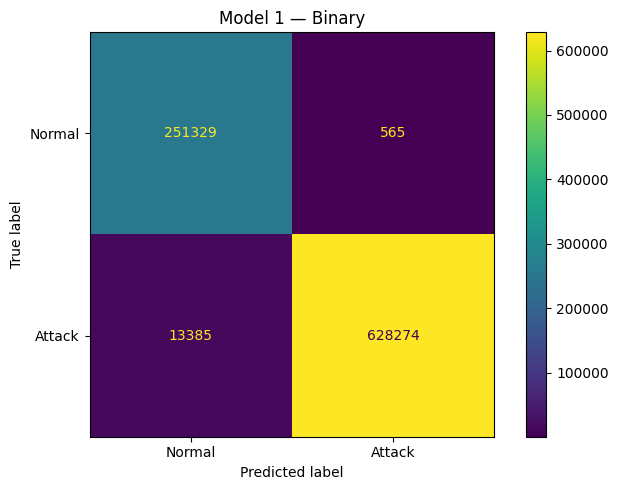

In [123]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Predictions 
y_pred_bin = model_binary_v1.predict(X_test)

# Accuracy
train_acc = accuracy_score(y_train2, model_binary_v1.predict(X_train2))
test_acc  = accuracy_score(y_test_bin, y_pred_bin)

print(f'Train: {train_acc:.4f} | Test: {test_acc:.4f} | Diff: {abs(train_acc-test_acc):.4f}')

# Classification Report 
print("\n Classification Report ")
print(classification_report(y_test_bin, y_pred_bin, target_names=['Normal','Attack']))

# Confusion Matrix
cm = confusion_matrix(y_test_bin, y_pred_bin)

fig, ax = plt.subplots(figsize=(7,5))
ConfusionMatrixDisplay(cm, display_labels=['Normal','Attack']).plot(ax=ax)
plt.title('Model 1 — Binary')
plt.tight_layout()
plt.show()

## 11.Top 20 Feature Selection

In [124]:
import pandas as pd

feat_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model_binary_v1.feature_importances_
}).sort_values('Importance', ascending=False)

TOP_N = 20
selected_features = feat_df.head(TOP_N)['Feature'].tolist()

print(f"Selected: {selected_features}")

Selected: ['deltatime', 'ip_flag_df', 'TCP Window Size', 'is_browser', 'ip_flag_none', 'tcp_rst', 'is_attack_tool', 'TCP Acknowledgment Number', 'is_http_1_0', 'has_dns_query', 'TCP Sequence Number', 'TCP Destination Port', 'Length', 'is_http_error', 'tcp_psh', 'TCP Stream', 'is_script', 'is_http_response', 'TCP Source Port', 'HTTP Content-Length']


C:\Users\USER\AppData\Local\Temp\ipykernel_5740\3831465342.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature',


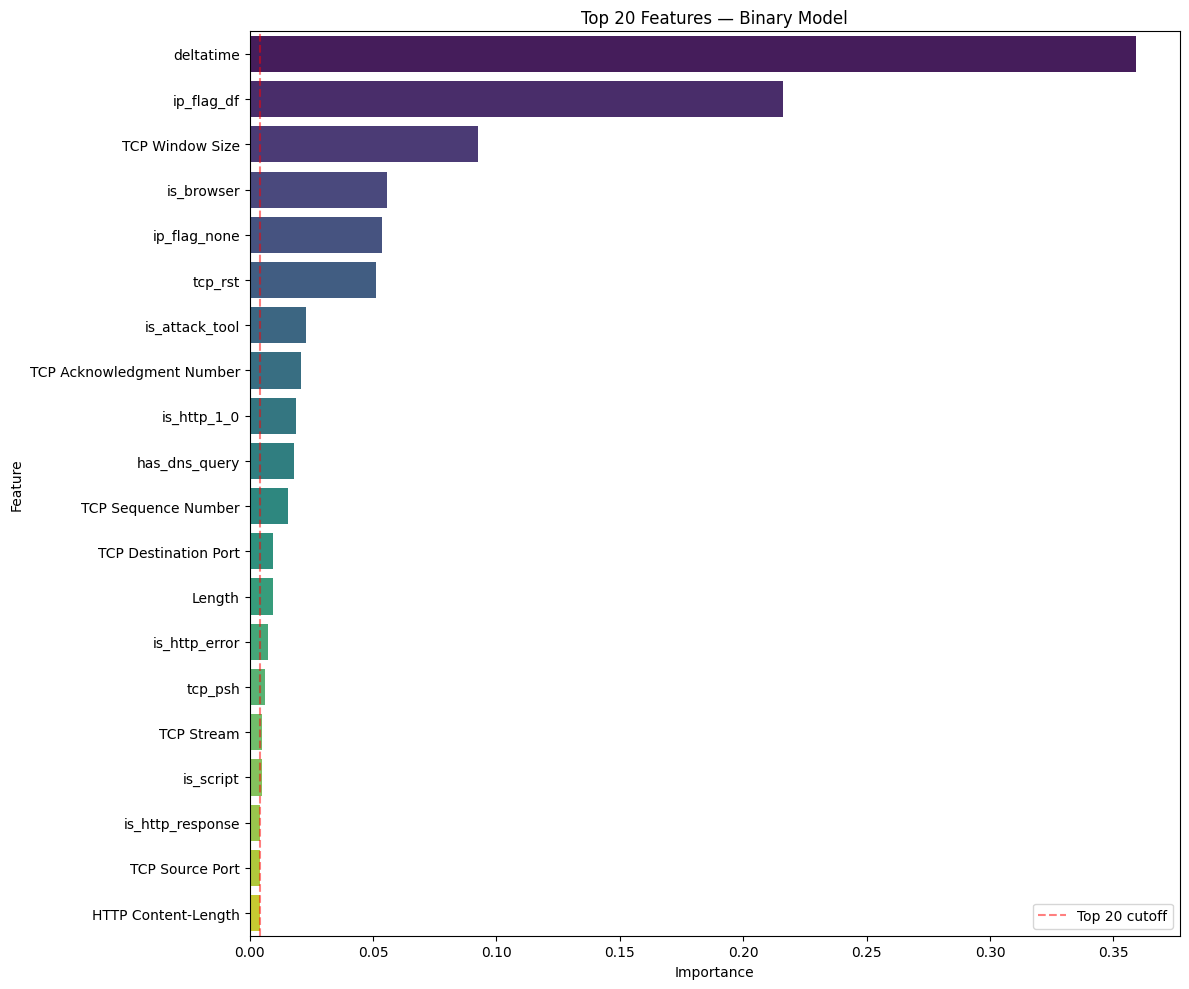

In [127]:
import seaborn as sns
# Plot
plt.figure(figsize=(12, 10))
sns.barplot(x='Importance', y='Feature', 
            data=feat_df.head(TOP_N), palette='viridis')
plt.axvline(x=feat_df.iloc[TOP_N-1]['Importance'], 
            color='red', linestyle='--', alpha=0.5, 
            label=f'Top {TOP_N} cutoff')
plt.title(f'Top {TOP_N} Features — Binary Model')
plt.legend()
plt.tight_layout()
plt.show()

In [128]:
# Select features
selected_features = feat_df.head(TOP_N)['Feature'].tolist()
dropped_features  = feat_df.iloc[TOP_N:]['Feature'].tolist()

print(f'\n Selected ({len(selected_features)}): {selected_features}')
print(f'  Dropped  ({len(dropped_features)}): {dropped_features}')

# Apply selection 
all_feature_names = X_train2.columns.tolist()
feat_idx = [all_feature_names.index(f) for f in selected_features]

X_train_sel_bin = X_train[selected_features]
X_test_sel_bin  = X_test[selected_features]


X_train22, X_val22, y_train22, y_val22 = train_test_split(
    X_train_sel_bin, y_train_bin,
    test_size=0.1,
    random_state=42,
    stratify=y_train_bin
)
#X_train_multi_sel = X_train[selected_features]
#X_test_multi_sel  = X_test[selected_features]




 Selected (20): ['deltatime', 'ip_flag_df', 'TCP Window Size', 'is_browser', 'ip_flag_none', 'tcp_rst', 'is_attack_tool', 'TCP Acknowledgment Number', 'is_http_1_0', 'has_dns_query', 'TCP Sequence Number', 'TCP Destination Port', 'Length', 'is_http_error', 'tcp_psh', 'TCP Stream', 'is_script', 'is_http_response', 'TCP Source Port', 'HTTP Content-Length']
  Dropped  (29): ['is_http_redirect', 'UDP Destination Port', 'uri_has_params', 'tcp_ack', 'is_http_request', 'Protocol', 'has_ip_source', 'IP TTL', 'is_http_success', 'tcp_syn', 'ICMP Type', 'UDP Source Port', 'is_icmp_packet', 'tcp_fin', 'is_suspicious_method', 'TCP SYN Flag', 'TCP ACK Flag', 'TCP RST Flag', 'TCP FIN Flag', 'is_tcp_packet', 'is_udp', 'tcp_seq_exists', 'tcp_stream_exists', 'tcp_ack_exists', 'tcp_urg', 'has_ip_dest', 'ip_flag_mf', 'is_ipv6', 'has_ttl']


In [129]:
import joblib, zlib, warnings
warnings.filterwarnings('ignore')
# Save
joblib.dump(selected_features, 'feature_names.pkl')
print('\n feature_names.pkl saved!')


 feature_names.pkl saved!


## 12. Retrain Model 1 — على الـ Top 20

In [130]:
from xgboost import XGBClassifier

model_binary = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=spw,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='auc',       
    tree_method='hist',
    random_state=42,
    n_jobs=-1,
)


model_binary.fit(
    X_train22,
    y_train22,
    eval_set=[(X_val22, y_val22)],
    verbose=50
)

[0]	validation_0-auc:0.98948
[50]	validation_0-auc:0.99651
[100]	validation_0-auc:0.99742
[150]	validation_0-auc:0.99789
[200]	validation_0-auc:0.99818
[250]	validation_0-auc:0.99835
[300]	validation_0-auc:0.99856
[350]	validation_0-auc:0.99874
[399]	validation_0-auc:0.99887


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

## 14. Evaluate Model 1 — Binary

Train: 0.9847 | Test: 0.9846 | Diff: 0.0001

 Classification Report 
              precision    recall  f1-score   support

      Normal       0.95      1.00      0.97    251894
      Attack       1.00      0.98      0.99    641659

    accuracy                           0.98    893553
   macro avg       0.97      0.99      0.98    893553
weighted avg       0.99      0.98      0.98    893553



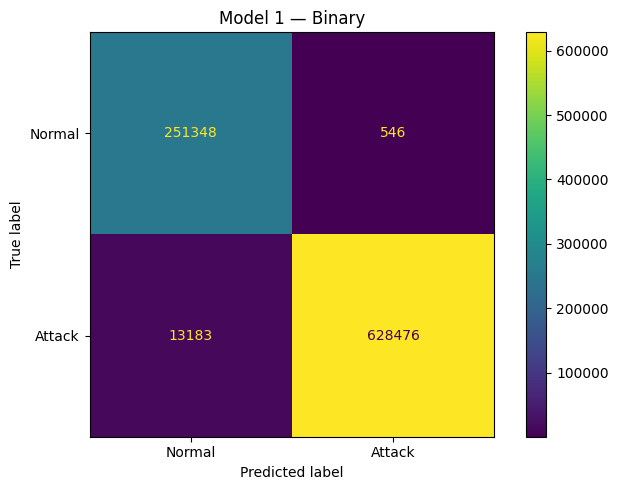

In [131]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Predictions 
y_pred_bin = model_binary.predict(X_test_sel_bin)

# Accuracy
train_acc = accuracy_score(y_train22, model_binary.predict(X_train22))
test_acc  = accuracy_score(y_test_bin, y_pred_bin)

print(f'Train: {train_acc:.4f} | Test: {test_acc:.4f} | Diff: {abs(train_acc-test_acc):.4f}')

# Classification Report 
print("\n Classification Report ")
print(classification_report(y_test_bin, y_pred_bin, target_names=['Normal','Attack']))

# Confusion Matrix
cm = confusion_matrix(y_test_bin, y_pred_bin)

fig, ax = plt.subplots(figsize=(7,5))
ConfusionMatrixDisplay(cm, display_labels=['Normal','Attack']).plot(ax=ax)
plt.title('Model 1 — Binary')
plt.tight_layout()
plt.show()

# STEP 15 => Save Binary Model & Assets


In [132]:
import os
import joblib

os.makedirs('models', exist_ok=True)

# Save model
joblib.dump(model_binary, 'models/model_binary.pkl')

# Save feature names (top 20)
joblib.dump(selected_features, 'models/feature_names_binary.pkl')

# Save label encoder for Protocol (fitted on X_train)
joblib.dump(le, 'models/label_encoder_protocol.pkl')

# Save top_protocols list (needed in preprocessing)
joblib.dump(top_protocols, 'models/top_protocols.pkl')

print("Saved successfully!")
print(f"  model_binary.pkl")
print(f"  feature_names_binary.pkl  — {len(selected_features)} features")
print(f"  label_encoder_protocol.pkl")
print(f"  top_protocols.pkl")

Saved successfully!
  model_binary.pkl
  feature_names_binary.pkl  — 20 features
  label_encoder_protocol.pkl
  top_protocols.pkl
